In [8]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [9]:
import pandas as pd

df_mf = pd.read_csv('../scripts/results/logscores_mf_linear.csv')
df_hk = pd.read_csv('../scripts/results/logscores_hk_linear.csv')
df_nargp = pd.read_csv('../scripts/results/logscores_nargp_linear.csv')
df_matern = pd.read_csv('../scripts/results/logscores_matern_linear.csv')
df_vae = pd.read_csv('../scripts/results/logscores_VAE_linear.csv')

In [10]:
df_mf_min = pd.read_csv('../scripts/results/logscores_mf_min.csv')
df_hk_min = pd.read_csv('../scripts/results/logscores_hk_min.csv')
df_nargp_min = pd.read_csv('../scripts/results/logscores_nargp_min.csv')
df_matern_min = pd.read_csv('../scripts/results/logscores_matern_min.csv')
df_vae_min = pd.read_csv('../scripts/results/logscores_VAE_min.csv')

In [11]:
import matplotlib.pyplot as plt

# Set global font size and style
plt.rc('font', size=10)  # Default font size for text
plt.rc('axes', titlesize=12)  # Font size for axes titles
plt.rc('axes', labelsize=10)  # Font size for x and y labels
plt.rc('xtick', labelsize=8)  # Font size for x-tick labels
plt.rc('ytick', labelsize=8)  # Font size for y-tick labels
plt.rc('legend', fontsize=9)  # Font size for legend
plt.rc('figure', titlesize=12)  # Font size for figure titles

# Optional: Set font family
plt.rc('font', family='serif')  # e.g., Times New Roman for a consistent style

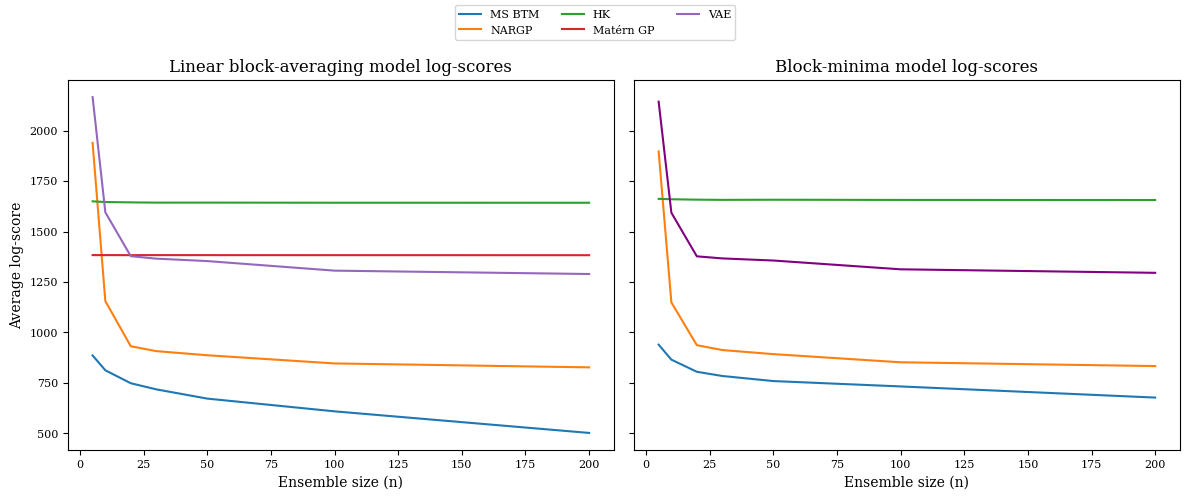

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# --- Left axis: "linear" family ---
ax_lin = axes[0]
ax_lin.plot(df_mf['n'],      df_mf['logscore'],      label="MS BTM")
ax_lin.plot(df_nargp['n'],   df_nargp['logscore'],   label="NARGP")
ax_lin.plot(df_hk['n'],      df_hk['logscore'],      label="HK")
ax_lin.plot(df_matern['n'],  df_matern['logscore'],  label="Matérn GP")
ax_lin.plot(df_vae['n'],     df_vae['logscore'],     label="VAE")  # default color

ax_lin.set_xlabel("Ensemble size (n)")
ax_lin.set_ylabel("Average log-score")
ax_lin.set_title("Linear block-averaging model log-scores")

# --- Right axis: "min" family ---
ax_min = axes[1]
ax_min.plot(df_mf_min['n'],      df_mf_min['logscore'],      label="MS BTM")
ax_min.plot(df_nargp_min['n'],   df_nargp_min['logscore'],   label="NARGP")
ax_min.plot(df_hk_min['n'],      df_hk_min['logscore'],      label="HK")
ax_min.plot(
    df_vae_min['n'],
    df_vae_min['logscore'],
    label="VAE",
    color="purple",   # enforce purple for VAE in second plot
)

ax_min.set_xlabel("Ensemble size (n)")
ax_min.set_title("Block-minima model log-scores")

# Shared legend
handles, labels = ax_lin.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.92])

OUTPUT_FILE = "logscores_sim.pdf"
DPI = 600
fig.savefig(OUTPUT_FILE, format="pdf", dpi=DPI, bbox_inches="tight")


# Plots

Here are the main log-score plots for the simulated data. Slighly different from the paper, changed some things in the computation to make them more stable, but in turn they also became a bit better, but not as much as the MF BTM, but the ranking between them changed slighlty. 

In [13]:
df_mf_c = pd.read_csv('../scripts/results/logscores_mf_climate.csv')
df_nargp_c = pd.read_csv('../scripts/results/logscores_nargp_climate.csv')
df_hk_c = pd.read_csv('../scripts/results/logscores_hk_climate.csv')
df_vae_c = pd.read_csv('../scripts/results/logscores_VAE_climate.csv')

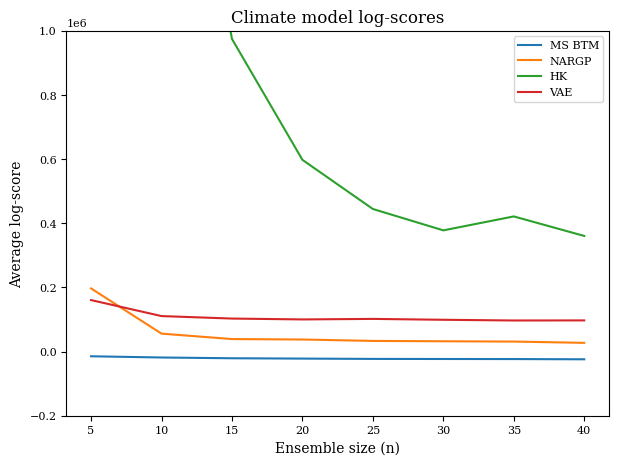

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

plt.plot(df_mf_c['n'], df_mf_c['logscore'], label="MS BTM")
plt.plot(df_nargp_c['n'], df_nargp_c['logscore_total_mean'], label = "NARGP")
plt.plot(df_hk_c['n'], df_hk_c['logscore'], label = "HK")
plt.plot(df_vae_c['n'], df_vae_c['logscore'], label = "VAE")
plt.legend(loc="lower left", prop={'size': 6})
plt.ylim(-0.2e6, 1e6)
ax.set_xlabel("Ensemble size (n)")
ax.set_ylabel("Average log-score")
ax.set_title("Climate model log-scores")
ax.legend(loc="upper right", prop={'size': 8})   
OUTPUT_FILE = "logscores_climate.pdf"
DPI = 600  # Specify the DPI
fig.savefig(OUTPUT_FILE, format='pdf', dpi=DPI, bbox_inches='tight')

Text(0.5, 1.0, 'Climate model log-scores for MF BTM only')

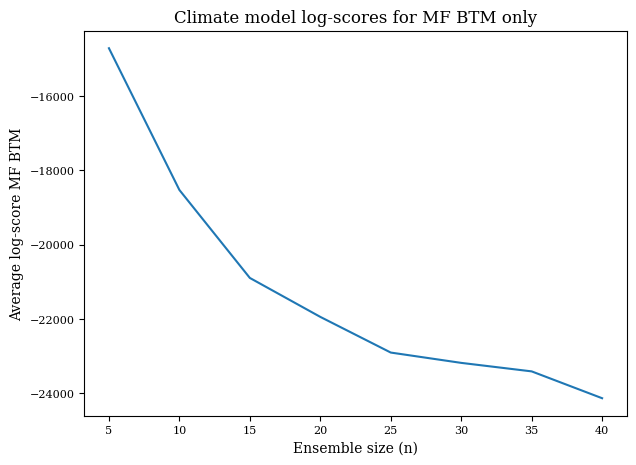

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.plot(df_mf_c['n'], df_mf_c['logscore'], label="MF BTM")
ax.set_xlabel("Ensemble size (n)")
ax.set_ylabel("Average log-score MF BTM")
ax.set_title("Climate model log-scores for MF BTM only")

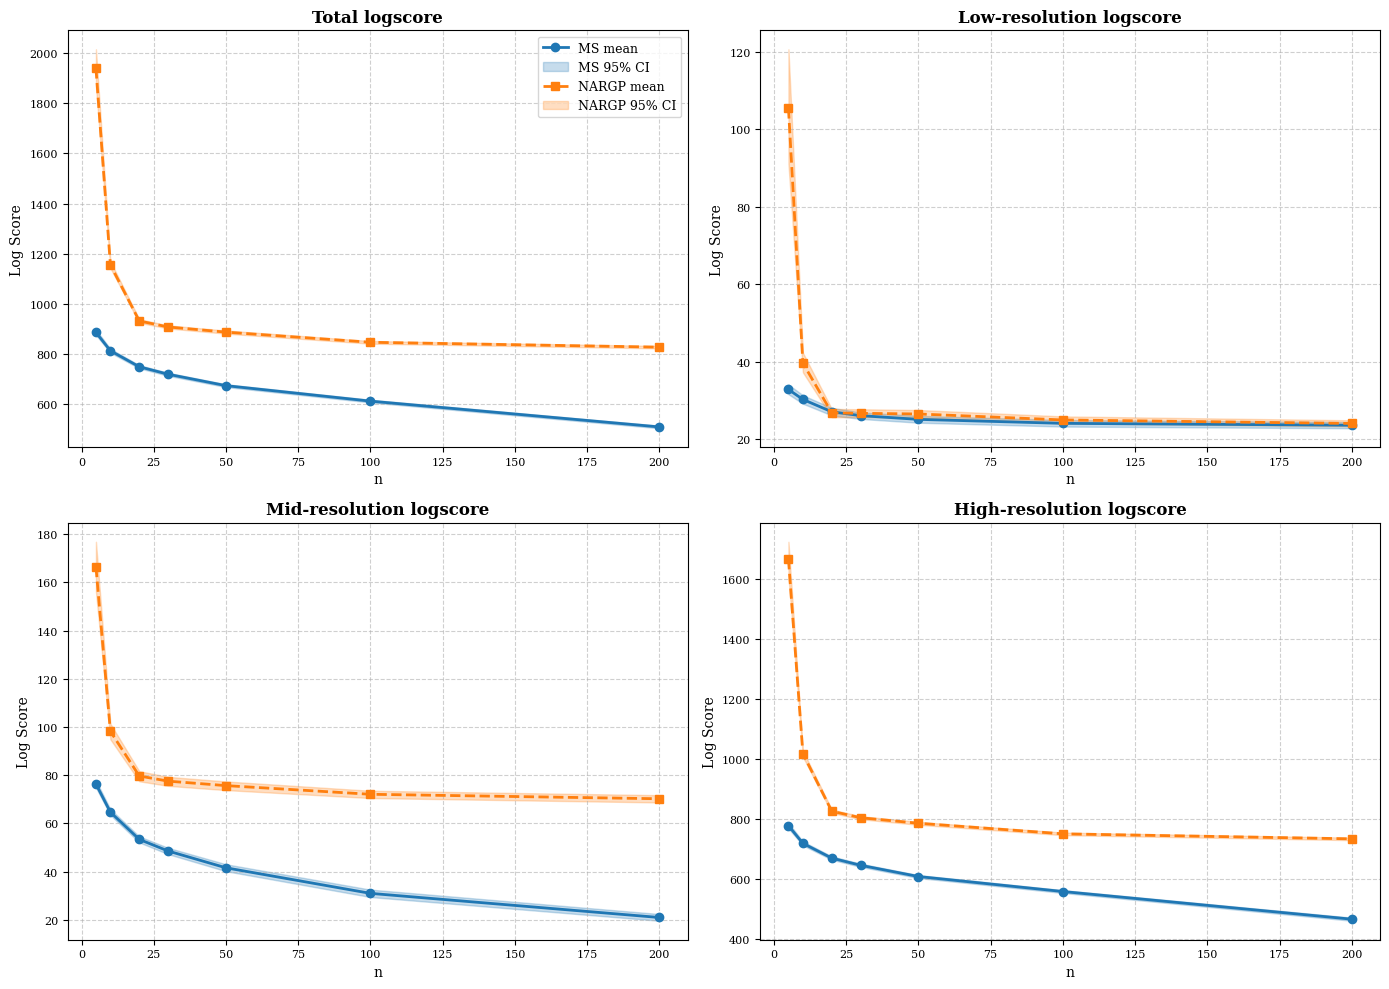

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load both result files ---
fp_mf    = "../scripts/results/logscores_mf_linear_allfields.csv"
fp_nargp = "../scripts/results/logscores_nargp_linear_allfields.csv"

df_mf    = pd.read_csv(fp_mf)
df_nargp = pd.read_csv(fp_nargp)

# Columns / panels
metrics = ['logscore_total', 'logscore_lf', 'logscore_mf', 'logscore_hf']
titles  = ['Total logscore', "Low-resolution logscore", "Mid-resolution logscore", "High-resolution logscore"]

# Use union of n's so both curves share the same x-axis
n_values = sorted(set(df_mf['n'].unique()).union(set(df_nargp['n'].unique())))

n_boot = 1000
rng = np.random.default_rng(0)  # reproducible bootstrap

def mean_and_boot_ci(df, n_values, col, n_boot, rng):
    means, lo, hi = [], [], []
    for n in n_values:
        data = df.loc[df["n"] == n, col].to_numpy()
        if data.size == 0:
            means.append(np.nan); lo.append(np.nan); hi.append(np.nan)
            continue

        means.append(data.mean())

        idx = rng.integers(0, data.size, size=(n_boot, data.size))
        boot_means = data[idx].mean(axis=1)
        lo.append(np.percentile(boot_means, 2.5))
        hi.append(np.percentile(boot_means, 97.5))
    return np.array(means), np.array(lo), np.array(hi)

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(metrics):
    ax = axes[i]

    # MF
    m_mean, m_lo, m_hi = mean_and_boot_ci(df_mf, n_values, col, n_boot, rng)
    line_mf = ax.plot(n_values, m_mean, marker='o', linewidth=2, label='MS mean')[0]
    c_mf = line_mf.get_color()
    ax.fill_between(n_values, m_lo, m_hi, alpha=0.25, color=c_mf, label='MS 95% CI')

    # NARGP
    n_mean, n_lo, n_hi = mean_and_boot_ci(df_nargp, n_values, col, n_boot, rng)
    line_ng = ax.plot(n_values, n_mean, marker='s', linewidth=2, linestyle='--', label='NARGP mean')[0]
    c_ng = line_ng.get_color()
    ax.fill_between(n_values, n_lo, n_hi, alpha=0.25, color=c_ng, label='NARGP 95% CI')

    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_xlabel('n')
    ax.set_ylabel('Log Score')
    ax.grid(True, linestyle='--', alpha=0.6)

    if i == 0:
        ax.legend()

plt.tight_layout()

# --- Save at 300 dpi ---
outpath = "../scripts/results/logscores_mf_vs_nargp_linear_allfields.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")

plt.show()

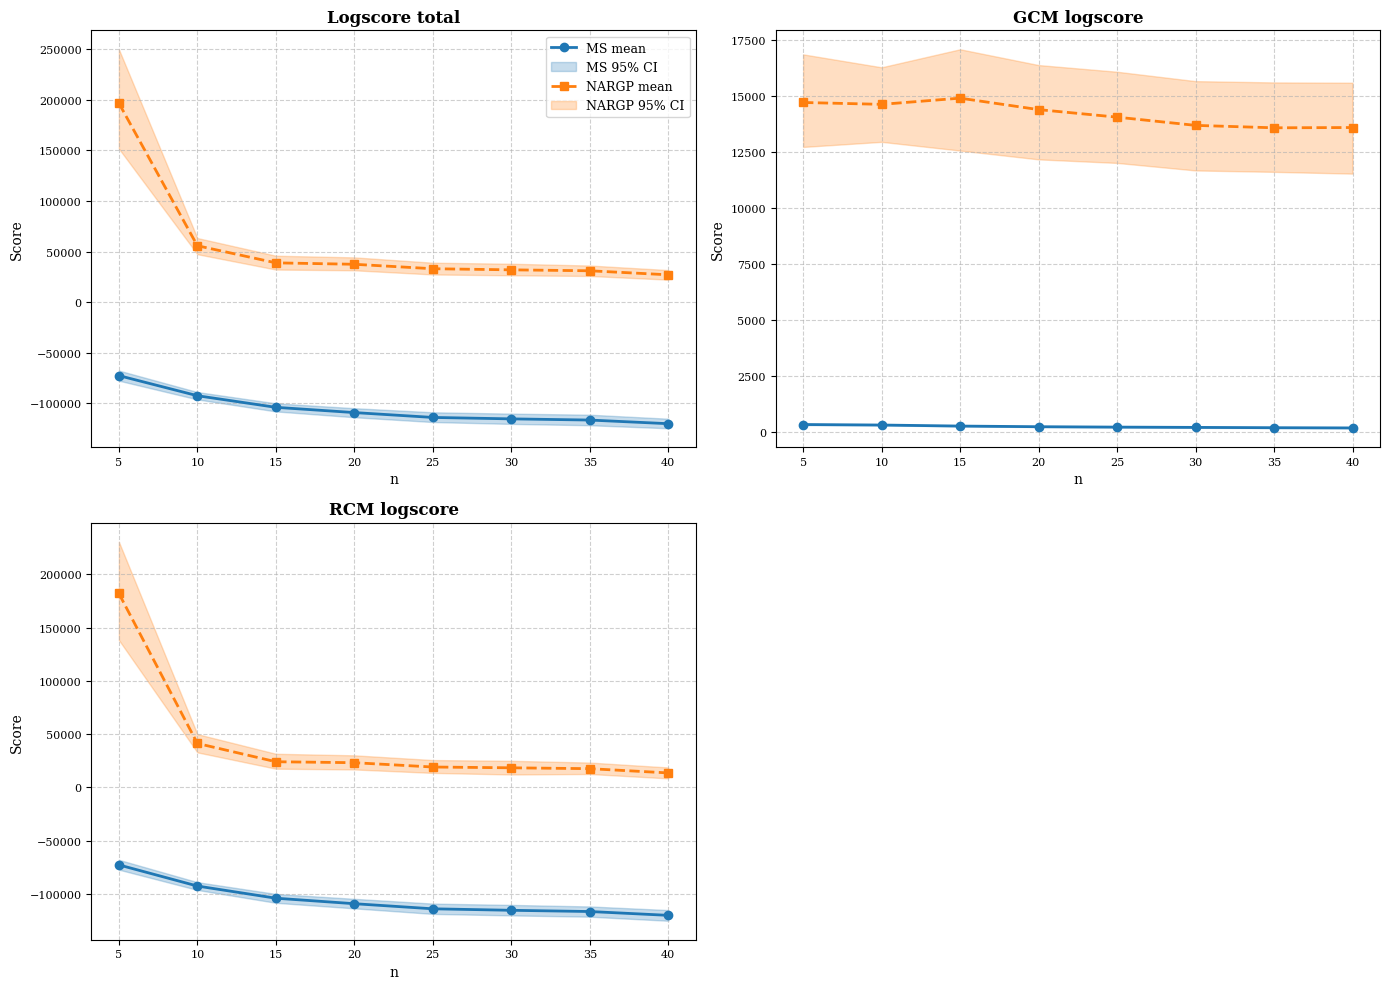

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load both result files ---
fp_mf    = "../scripts/results/logscores_mf_climate_allfields.csv"         
fp_nargp = "../scripts/results/logscores_nargp_climate_allfields.csv"    

df_mf    = pd.read_csv(fp_mf)
df_nargp = pd.read_csv(fp_nargp)

# Define the columns to plot + desired titles
metrics = ['logscore_total', 'logscore_gcm', 'logscore_rcm']
titles  = ['Logscore total', 'GCM logscore', 'RCM logscore']

# Setup the figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Use union of n's so both curves share the same x-axis
n_values = sorted(set(df_mf['n'].unique()).union(set(df_nargp['n'].unique())))
n_boot = 1000
rng = np.random.default_rng(0)  # reproducible bootstrap

def mean_and_boot_ci(df, n_values, col, n_boot, rng):
    means, lo, hi = [], [], []
    for n in n_values:
        data = df.loc[df["n"] == n, col].to_numpy()
        if data.size == 0:
            means.append(np.nan); lo.append(np.nan); hi.append(np.nan)
            continue

        means.append(data.mean())

        idx = rng.integers(0, data.size, size=(n_boot, data.size))
        boot_means = data[idx].mean(axis=1)
        lo.append(np.percentile(boot_means, 2.5))
        hi.append(np.percentile(boot_means, 97.5))
    return np.array(means), np.array(lo), np.array(hi)

for i, col in enumerate(metrics):
    ax = axes[i]

    # MF (original)
    m_mean, m_lo, m_hi = mean_and_boot_ci(df_mf, n_values, col, n_boot, rng)
    line_mf = ax.plot(n_values, m_mean, marker='o', linewidth=2, label='MS mean')[0]
    c_mf = line_mf.get_color()
    ax.fill_between(n_values, m_lo, m_hi, alpha=0.25, color=c_mf, label='MS 95% CI')

    # NARGP overlay
    n_mean, n_lo, n_hi = mean_and_boot_ci(df_nargp, n_values, col, n_boot, rng)
    line_ng = ax.plot(n_values, n_mean, marker='s', linewidth=2, linestyle='--', label='NARGP mean')[0]
    c_ng = line_ng.get_color()
    ax.fill_between(n_values, n_lo, n_hi, alpha=0.25, color=c_ng, label='NARGP 95% CI')

    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_xlabel('n')
    ax.set_ylabel('Score')
    ax.grid(True, linestyle='--', alpha=0.6)

    if i == 0:
        ax.legend()

# Hide the empty 4th subplot
for j in range(len(metrics), 4):
    axes[j].axis('off')

plt.tight_layout()

# --- Save at 300 dpi ---
outpath = "../scripts/results/logscores_climate_mf_vs_nargp_allfields.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")

plt.show()

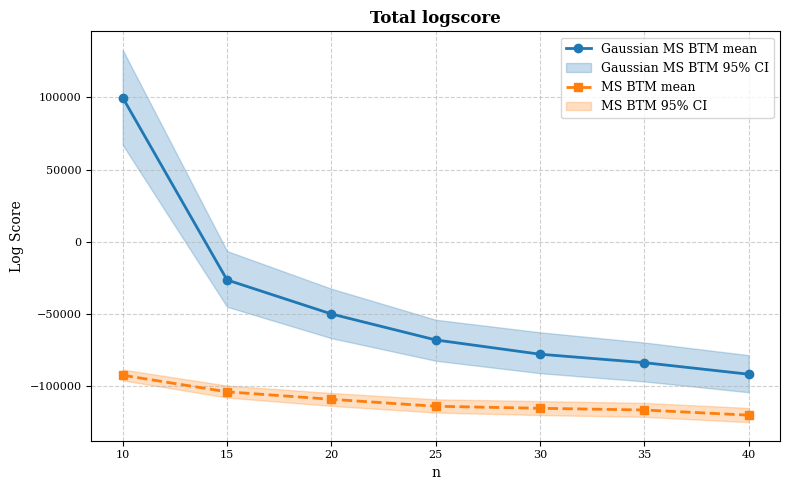

In [20]:
# --- Load both result files ---
fp_a = "../scripts/results/logscores_mflinear_climate_allfields.csv"
fp_b = "../scripts/results/logscores_mf_climate_allfields.csv"

df_a = pd.read_csv(fp_a)
df_b = pd.read_csv(fp_b)

col = "logscore_total"
title = "Total logscore"

# Use union of n's so both curves share the same x-axis
n_values = sorted(set(df_a['n'].unique()).union(set(df_b['n'].unique())))

# NEW: start at n=10
n_values = [n for n in n_values if n >= 10]

n_boot = 1000
rng = np.random.default_rng(0)  # reproducible bootstrap

def mean_and_boot_ci(df, n_values, col, n_boot, rng):
    means, lo, hi = [], [], []
    for n in n_values:
        data = df.loc[df["n"] == n, col].to_numpy()
        if data.size == 0:
            means.append(np.nan); lo.append(np.nan); hi.append(np.nan)
            continue

        means.append(data.mean())

        idx = rng.integers(0, data.size, size=(n_boot, data.size))
        boot_means = data[idx].mean(axis=1)
        lo.append(np.percentile(boot_means, 2.5))
        hi.append(np.percentile(boot_means, 97.5))
    return np.array(means), np.array(lo), np.array(hi)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

# File A: MFLinear
a_mean, a_lo, a_hi = mean_and_boot_ci(df_a, n_values, col, n_boot, rng)
line_a = ax.plot(n_values, a_mean, marker='o', linewidth=2, label='Gaussian MS BTM mean')[0]
c_a = line_a.get_color()
ax.fill_between(n_values, a_lo, a_hi, alpha=0.25, color=c_a, label='Gaussian MS BTM 95% CI')

# File B: MF
b_mean, b_lo, b_hi = mean_and_boot_ci(df_b, n_values, col, n_boot, rng)
line_b = ax.plot(n_values, b_mean, marker='s', linewidth=2, linestyle='--', label='MS BTM mean')[0]
c_b = line_b.get_color()
ax.fill_between(n_values, b_lo, b_hi, alpha=0.25, color=c_b, label='MS BTM 95% CI')

ax.set_title(title, fontsize=12, fontweight='bold')
ax.set_xlabel('n')
ax.set_ylabel('Log Score')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()

plt.tight_layout()

# --- Save at 300 dpi ---
outpath = "../scripts/results/logscore_total_mflinear_vs_mf_linear_allfields.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")

plt.show()